1 - Plot the Repos by age group and add the age group next to the main speadsheet

✅ Saved updated CSV with quartile age_group: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests.csv
✅ Clean Distribution DataFrame (each subgroup sums to 100%):
            Unit Test - Local  Unit Test - CI  Instr Test - Local  \
age_group                                                          
Q1                 13.636364       28.581013           15.170940   
Q2                 23.846154       27.876551           27.884615   
Q3                 33.776224       23.079504           36.111111   
Q4                 28.741259       20.462932           20.833333   

           Instr Test - CI  
age_group                   
Q1               19.815668  
Q2               31.797235  
Q3               22.119816  
Q4               26.267281  

Check sums:
 Unit Test - Local     100.0
Unit Test - CI        100.0
Instr Test - Local    100.0
Instr Test - CI       100.0
dtype: float64


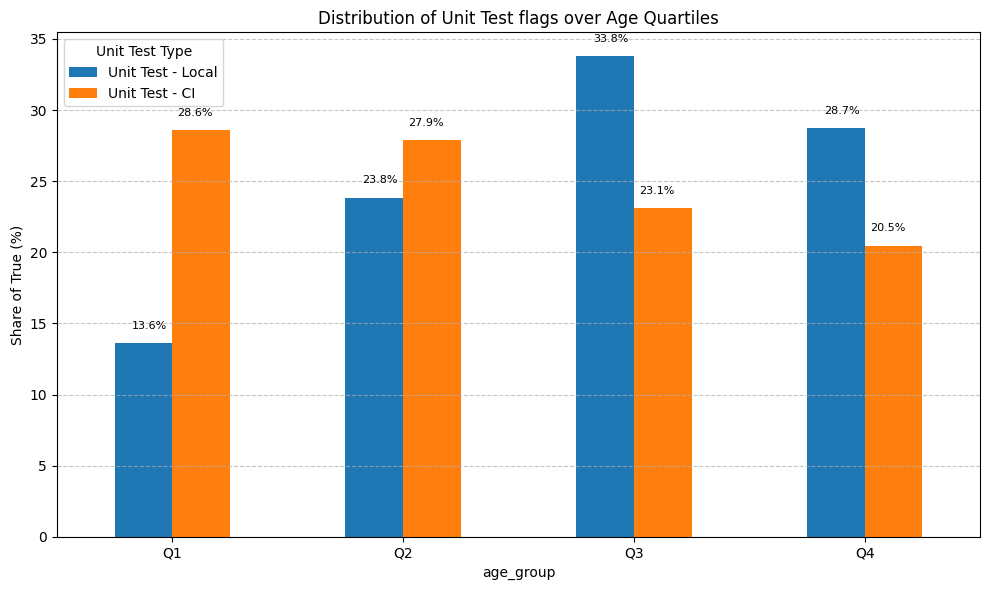

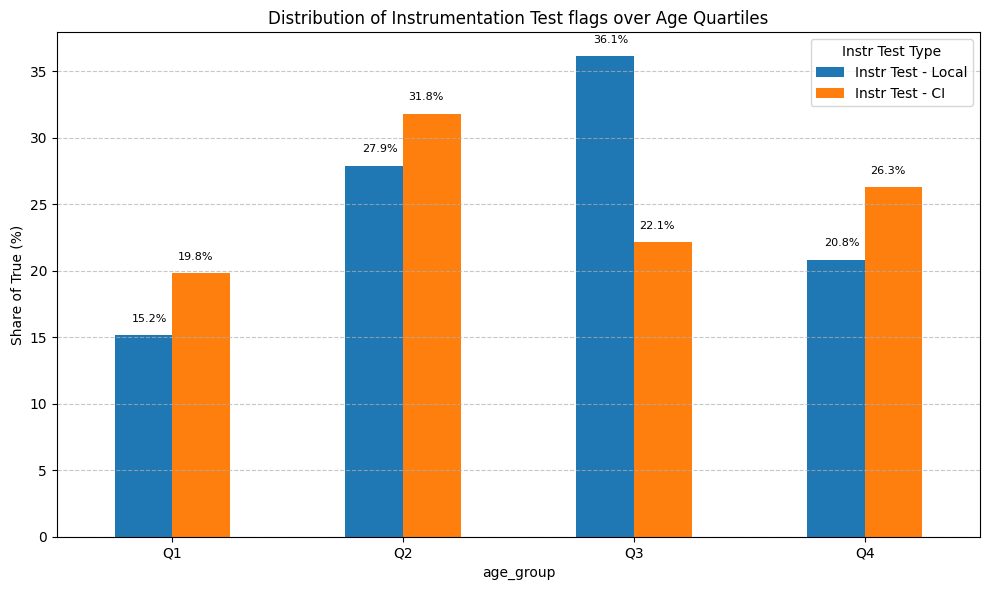

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests.csv"
output_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci",
    "Unit_Test(CI or Local)", "Instr_Test(CI or Local)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === Compute project age and drop blanks FIRST ===
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce").dt.tz_localize(None)
df["project_age_years"] = (pd.Timestamp.now() - df["created_at"]).dt.days / 365.25

# Keep only rows with valid project age
df = df.dropna(subset=["project_age_years"])

# === Define quartile age groups ===
df["age_group"] = pd.qcut(df["project_age_years"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

# === Save updated CSV with age_group at the end ===
cols = [col for col in df.columns if col != "age_group"] + ["age_group"]
df = df[cols]
df.to_csv(output_path, index=False)
print(f"✅ Saved updated CSV with quartile age_group: {file_path}")

# === Compute True distributions per quartile for each subgroup ===
flags = {
    "Unit Test - Local": "unit_test_local",
    "Unit Test - CI": "unit_test_ci",
    "Instr Test - Local": "instr_test_local",
    "Instr Test - CI": "instr_test_ci"
}

distribution = []

for label, col in flags.items():
    # For each flag, only use rows where project_age_years is valid
    flag_df = df[df[col] & df["age_group"].notna()]
    total_true = flag_df.shape[0]
    counts = flag_df.groupby("age_group", observed=True).size()
    percentages = (counts / total_true * 100).reindex(["Q1", "Q2", "Q3", "Q4"]).fillna(0)
    distribution.append(percentages)

distribution_df = pd.DataFrame(distribution, index=flags.keys()).T
print("✅ Clean Distribution DataFrame (each subgroup sums to 100%):\n", distribution_df)
print("\nCheck sums:\n", distribution_df.sum())

# === Split into Unit and Instr DataFrames ===
unit_df = distribution_df[["Unit Test - Local", "Unit Test - CI"]]
instr_df = distribution_df[["Instr Test - Local", "Instr Test - CI"]]

# === Plot Unit Tests ===
ax1 = unit_df.plot(kind="bar", figsize=(10, 6))
ax1.set_ylabel("Share of True (%)")
ax1.set_title("Distribution of Unit Test flags over Age Quartiles")
ax1.set_xticklabels(unit_df.index, rotation=0)
ax1.legend(title="Unit Test Type")
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(unit_df.index):
    for j, value in enumerate(unit_df.loc[quartile]):
        ax1.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# === Plot Instr Tests ===
ax2 = instr_df.plot(kind="bar", figsize=(10, 6))
ax2.set_ylabel("Share of True (%)")
ax2.set_title("Distribution of Instrumentation Test flags over Age Quartiles")
ax2.set_xticklabels(instr_df.index, rotation=0)
ax2.legend(title="Instr Test Type")
ax2.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(instr_df.index):
    for j, value in enumerate(instr_df.loc[quartile]):
        ax2.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


2 - Plot the Repos by age group and add the age group next to the main speadsheet Only for Isntru Test

✅ Saved updated CSV with quartile age_group: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv
✅ Rate of True (%) within each quartile:
            Unit Test - Local  Unit Test - CI  Instr Test - Local  \
age_group                                                          
Q1                 22.491349       98.269896           16.378316   
Q2                 39.240506       95.627158           30.034522   
Q3                 56.097561       79.907085           39.256678   
Q4                 47.459584       70.438799           22.517321   

           Instr Test - CI  
age_group                   
Q1                4.959631  
Q2                7.940161  
Q3                5.574913  
Q4                6.581986  


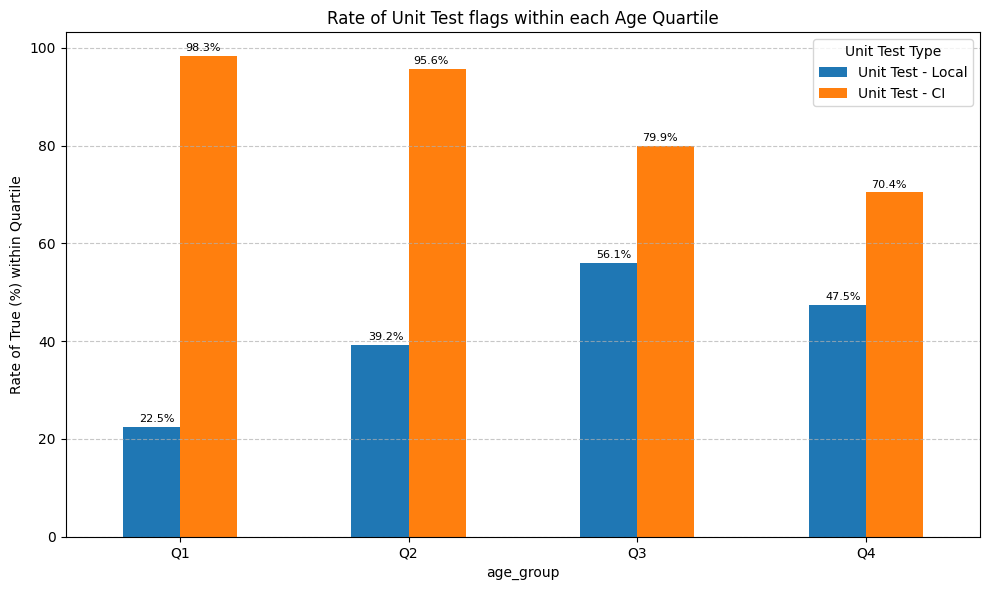

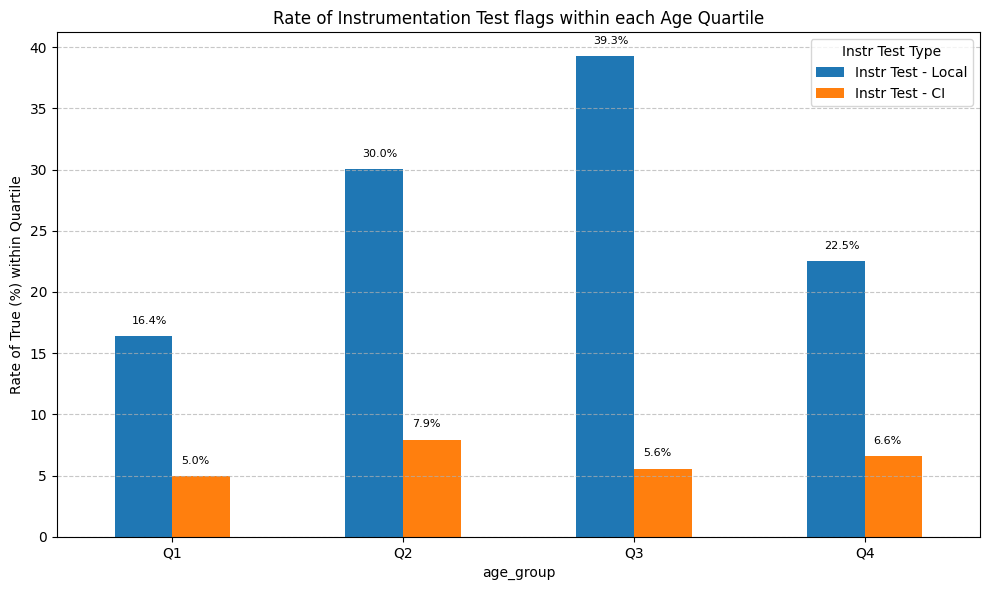

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci",
    "Unit_Test(CI or Local)", "Instr_Test(CI or Local)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === Compute project age and drop blanks ===
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce").dt.tz_localize(None)
df["project_age_years"] = (pd.Timestamp.now() - df["created_at"]).dt.days / 365.25

# Keep only rows with valid age
df = df.dropna(subset=["project_age_years"])

# === Define quartiles ===
df["age_group"] = pd.qcut(df["project_age_years"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

# Save updated CSV with quartile
cols = [col for col in df.columns if col != "age_group"] + ["age_group"]
df = df[cols]
df.to_csv(file_path, index=False)
print(f"✅ Saved updated CSV with quartile age_group: {file_path}")

# === Compute rate of True in each quartile ===
flags = {
    "Unit Test - Local": "unit_test_local",
    "Unit Test - CI": "unit_test_ci",
    "Instr Test - Local": "instr_test_local",
    "Instr Test - CI": "instr_test_ci"
}

rate_data = []

for label, col in flags.items():
    grouped = df.groupby("age_group", observed=True)[col].mean() * 100
    rate_data.append(grouped.reindex(["Q1", "Q2", "Q3", "Q4"]).fillna(0))

rate_df = pd.DataFrame(rate_data, index=flags.keys()).T
print("✅ Rate of True (%) within each quartile:\n", rate_df)

# === Split into Unit & Instr ===
unit_rate_df = rate_df[["Unit Test - Local", "Unit Test - CI"]]
instr_rate_df = rate_df[["Instr Test - Local", "Instr Test - CI"]]

# === Plot Unit Tests ===
ax1 = unit_rate_df.plot(kind="bar", figsize=(10, 6))
ax1.set_ylabel("Rate of True (%) within Quartile")
ax1.set_title("Rate of Unit Test flags within each Age Quartile")
ax1.set_xticklabels(unit_rate_df.index, rotation=0)
ax1.legend(title="Unit Test Type")
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(unit_rate_df.index):
    for j, value in enumerate(unit_rate_df.loc[quartile]):
        ax1.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# === Plot Instr Tests ===
ax2 = instr_rate_df.plot(kind="bar", figsize=(10, 6))
ax2.set_ylabel("Rate of True (%) within Quartile")
ax2.set_title("Rate of Instrumentation Test flags within each Age Quartile")
ax2.set_xticklabels(instr_rate_df.index, rotation=0)
ax2.legend(title="Instr Test Type")
ax2.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(instr_rate_df.index):
    for j, value in enumerate(instr_rate_df.loc[quartile]):
        ax2.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


Plot the age-group quartiles boxplot

Grouping the repos to these tiers: 

    Tier 1 – CI-Tested Instrumentation
    Tier 2 – Locally-Tested Instrumentation
    Tier 3 – Unite-Tested Only
    Tier 4 – Untested
Saves the Tier of each Repo in the main spreadsheet



✅ Saved updated CSV with Tier: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv
✅ Tier counts:
 Tier
Tier 1 - CI-Tested Instrumentation          217
Tier 2 - Locally-Tested Instrumentation     847
Tier 3 - Unit Tests Only                   2148
Tier 4 - Untested                           251
Name: count, dtype: int64
✅ Tier rates (%):
 Tier
Tier 1 - CI-Tested Instrumentation          6.3
Tier 2 - Locally-Tested Instrumentation    24.5
Tier 3 - Unit Tests Only                   62.0
Tier 4 - Untested                           7.2
Name: count, dtype: float64


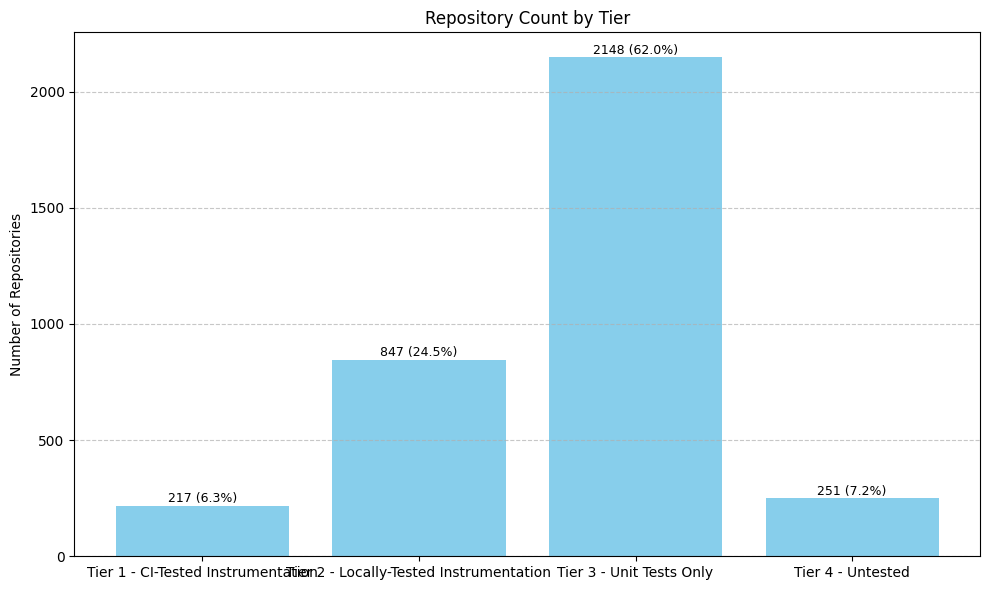

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci",
    "Unit_Test(CI or Local)", "Instr_Test(CI or Local)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === Drop rows with missing critical info (optional: based on created_at or tests) ===
# Here, assume no created_at check needed for Tiers; focus on test flags only.
df = df.dropna(subset=[
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci"
])

# === Define Tier logic ===
def assign_tier(row):
    if row["instr_test_ci"]:
        return "Tier 1 - CI-Tested Instrumentation"
    elif row["instr_test_local"] and not row["instr_test_ci"]:
        return "Tier 2 - Locally-Tested Instrumentation"
    elif ((row["unit_test_local"] or row["unit_test_ci"]) and not (row["instr_test_local"] or row["instr_test_ci"])):
        return "Tier 3 - Unit Tests Only"
    else:
        return "Tier 4 - Untested"

df["Tier"] = df.apply(assign_tier, axis=1)

# === Reorder columns to place Tier at end ===
cols = [col for col in df.columns if col != "Tier"] + ["Tier"]
df = df[cols]

# === Save updated CSV ===
df.to_csv(file_path, index=False)
print(f"✅ Saved updated CSV with Tier: {file_path}")

# === Compute counts and rates ===
tier_counts = df["Tier"].value_counts().sort_index()
tier_rates = (tier_counts / tier_counts.sum() * 100).round(1)
print("✅ Tier counts:\n", tier_counts)
print("✅ Tier rates (%):\n", tier_rates)

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(tier_counts.index, tier_counts.values, color='skyblue')

# Add labels: count + rate
for bar, count, rate in zip(bars, tier_counts.values, tier_rates.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f"{count} ({rate:.1f}%)",
            ha='center', va='bottom', fontsize=9)

ax.set_ylabel("Number of Repositories")
ax.set_title("Repository Count by Tier")
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


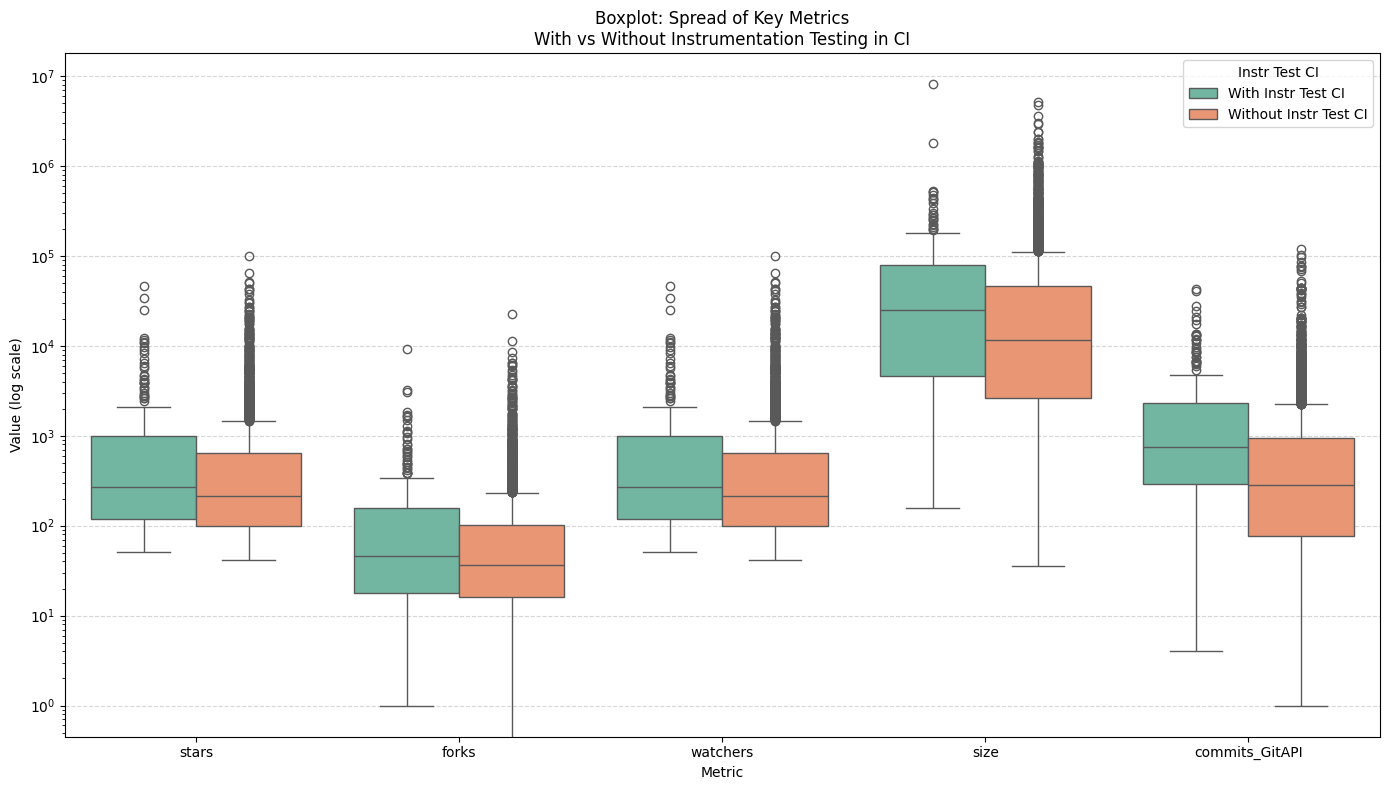

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === LOAD ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"
df = pd.read_csv(file_path)

# === Prepare columns ===
df["instr_test_ci"] = df["instr_test_ci"].astype(str).str.lower() == "true"
df["stars"] = pd.to_numeric(df["stargazers_count"], errors="coerce")
df["forks"] = pd.to_numeric(df["forks_count"], errors="coerce")
df["watchers"] = pd.to_numeric(df["watchers_count"], errors="coerce")
df["size"] = pd.to_numeric(df["size"], errors="coerce")
df["commits_GitAPI"] = pd.to_numeric(df["commits_GitAPI"], errors="coerce")

# === Melt for seaborn ===
metrics = ["stars", "forks", "watchers", "size", "commits_GitAPI"]
df_box = df[["instr_test_ci"] + metrics].copy()
df_box["instr_test_ci"] = df_box["instr_test_ci"].map({True: "With Instr Test CI", False: "Without Instr Test CI"})
df_melted = df_box.melt(id_vars="instr_test_ci", var_name="Metric", value_name="Value")

# === Boxplot ===
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_melted, x="Metric", y="Value", hue="instr_test_ci", palette="Set2")
plt.title("Boxplot: Spread of Key Metrics\nWith vs Without Instrumentation Testing in CI")
plt.ylabel("Value (log scale)")
plt.xlabel("Metric")
plt.yscale("log")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Instr Test CI")
plt.tight_layout()
plt.show()


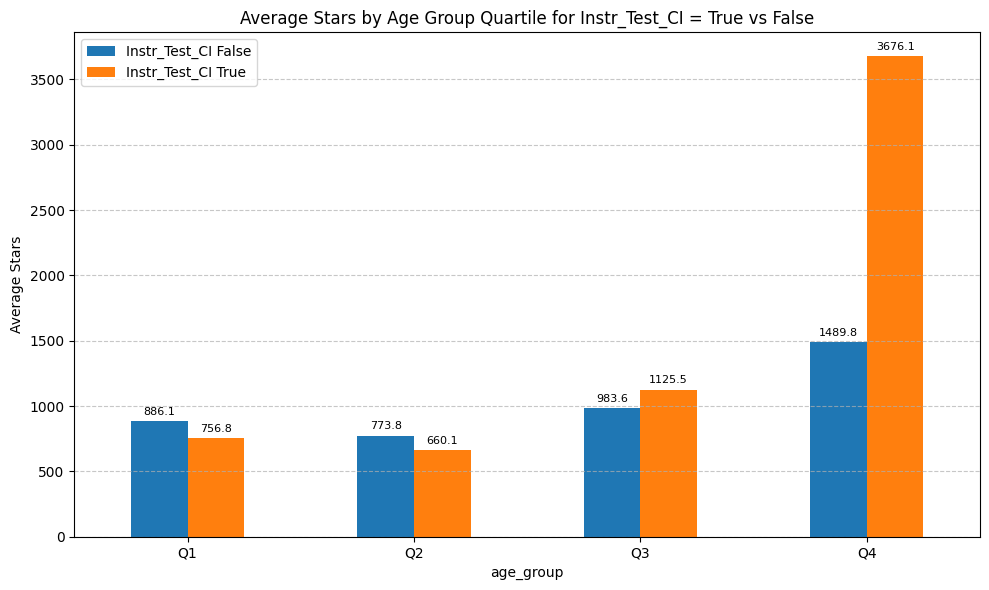

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert Instr_Test_CI to boolean and stars to numeric ===
df["instr_test_ci"] = df["instr_test_ci"].astype(str).str.lower() == "true"
df["stars"] = pd.to_numeric(df["stargazers_count"], errors="coerce")

# === Drop rows with missing age_group or stars ===
df = df.dropna(subset=["age_group", "stars"])

# === Compute mean stars for each age_group & Instr_Test_CI ===
avg_stars = df.groupby(["age_group", "instr_test_ci"])["stars"].mean().unstack(fill_value=0)

# === Rename columns for clarity ===
avg_stars.columns = ["Instr_Test_CI False", "Instr_Test_CI True"]

# === Sort by quartile order ===
avg_stars = avg_stars.reindex(["Q1", "Q2", "Q3", "Q4"])

# === Plot ===
ax = avg_stars.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Average Stars")
ax.set_title("Average Stars by Age Group Quartile for Instr_Test_CI = True vs False")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=0)

# === Add data labels ===
for i, bar_group in enumerate(ax.containers):
    for bar in bar_group:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # offset in points
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


📊 Language Frequency:
            Language  Count
0             Kotlin   1170
1               Java   1043
2               Dart    542
3                C++    191
4         TypeScript    148
5         JavaScript     99
6                  C     86
7               Rust     28
8             Python     19
9        Objective-C     18
10              HTML     17
11                Go     15
12                C#     12
13               Vue     11
14             Swift      9
15             Scala      7
16               NaN      5
17            Svelte      5
18  Jupyter Notebook      4
19            Groovy      3
20               QML      3
21             Shell      3
22               Lua      3
23     Objective-C++      2
24           Clojure      2
25               Nim      2
26                 D      2
27               CSS      2
28               Red      1
29               Nix      1
30            Scheme      1
31          Mustache      1
32               PHP      1
33              Vala      

<Figure size 1000x500 with 0 Axes>

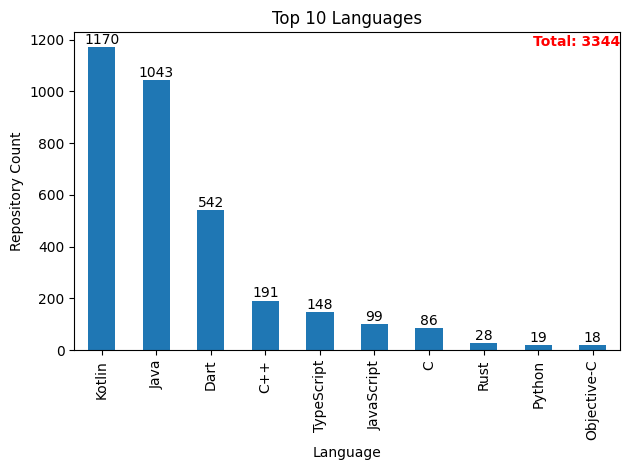

<Figure size 640x480 with 0 Axes>

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# === FILE PATH ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"

# === LOAD DATA ===
df = pd.read_csv(file_path)

# === LANGUAGE FREQUENCY ===
language_counts = df['language'].value_counts(dropna=False).reset_index()
language_counts.columns = ['Language', 'Count']
language_top10 = language_counts.head(10)
language_total = language_top10['Count'].sum()

# === YML CI PLATFORM FREQUENCY (excluding 'Error') ===
ci_yml = df['ci_platform_yml'].dropna().str.split(',', expand=True).stack().str.strip()
ci_yml = ci_yml[ci_yml.str.lower() != 'error']  # Remove 'Error'
ci_yml_counts = ci_yml.value_counts().reset_index()
ci_yml_counts.columns = ['YML CI Platform', 'Count']
ci_top10 = ci_yml_counts.head(10)
ci_total = ci_top10['Count'].sum()

# === DISPLAY TABLES ===
print("📊 Language Frequency:")
print(language_counts)
print("\n📊 YML CI Platform Frequency (excluding 'Error'):")
print(ci_yml_counts)

# === PLOT LANGUAGE FREQUENCY WITH LABELS AND TOTAL ===
plt.figure(figsize=(10, 5))
ax1 = language_top10.plot(kind='bar', x='Language', y='Count', legend=False, title='Top 10 Languages')
plt.ylabel("Repository Count")
for i, v in enumerate(language_top10['Count']):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom')

# Add total count at the end
ax1.text(len(language_top10) - 0.5, language_top10['Count'].max() + 5, f"Total: {language_total}", fontsize=10, color='red', fontweight='bold', ha='right')
plt.tight_layout()
plt.show()


# Add total count at the end
ax2.text(len(ci_top10) - 0.5, ci_top10['Count'].max() + 5, f"Total: {ci_total}", fontsize=10, color='red', fontweight='bold', ha='right')
plt.tight_layout()
plt.show()


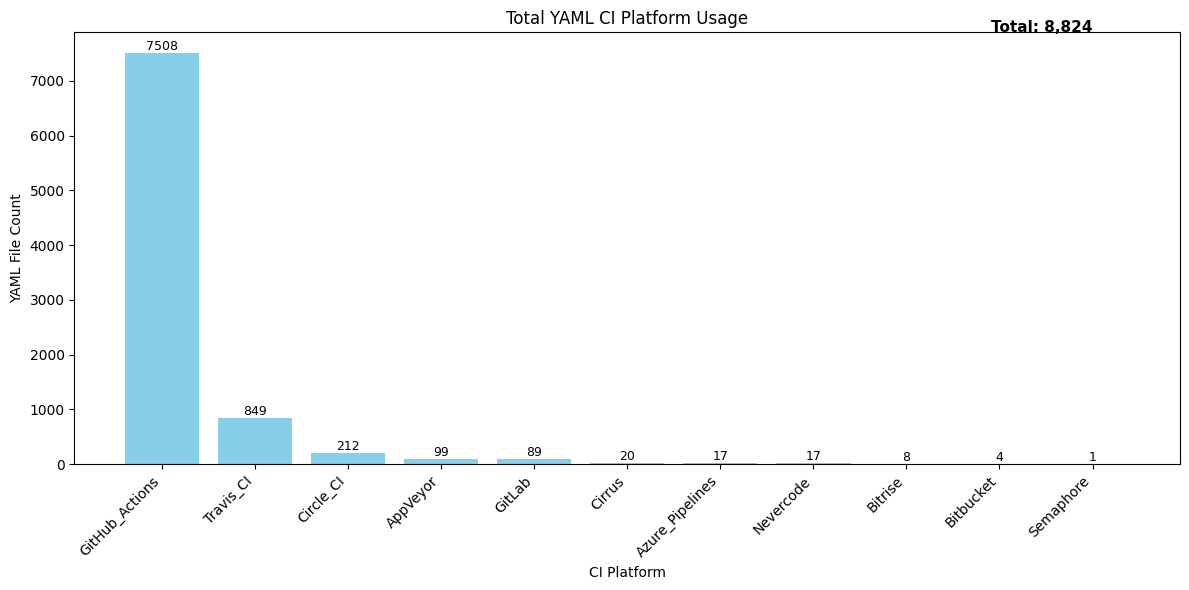

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# === FILE PATH ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"

# === LOAD DATA ===
df = pd.read_csv(file_path)

# === SELECT YML COLUMNS (EXCLUDE 'yml_Error') ===
yml_columns = [col for col in df.columns if col.startswith('yml_') and col.lower() != 'yml_error']

# === CONVERT YML COLUMNS TO NUMERIC (IN CASE OF ANY NON-NUMERIC VALUES) ===
df[yml_columns] = df[yml_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# === CALCULATE TOTAL COUNTS FOR EACH CI PLATFORM ===
ci_totals = df[yml_columns].sum().sort_values(ascending=False)
ci_totals = ci_totals[ci_totals > 0]

# === PLOT ===
plt.figure(figsize=(12, 6))
bars = plt.bar(ci_totals.index.str.replace('yml_', ''), ci_totals.values, color='skyblue')
plt.title('Total YAML CI Platform Usage')
plt.xlabel('CI Platform')
plt.ylabel('YAML File Count')

# === ADD LABELS TO EACH BAR ===
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

# === ADD GRAND TOTAL LABEL ===
total_count = int(ci_totals.sum())
plt.text(len(ci_totals)-1, max(ci_totals)*1.05, f'Total: {total_count:,}', ha='right', fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


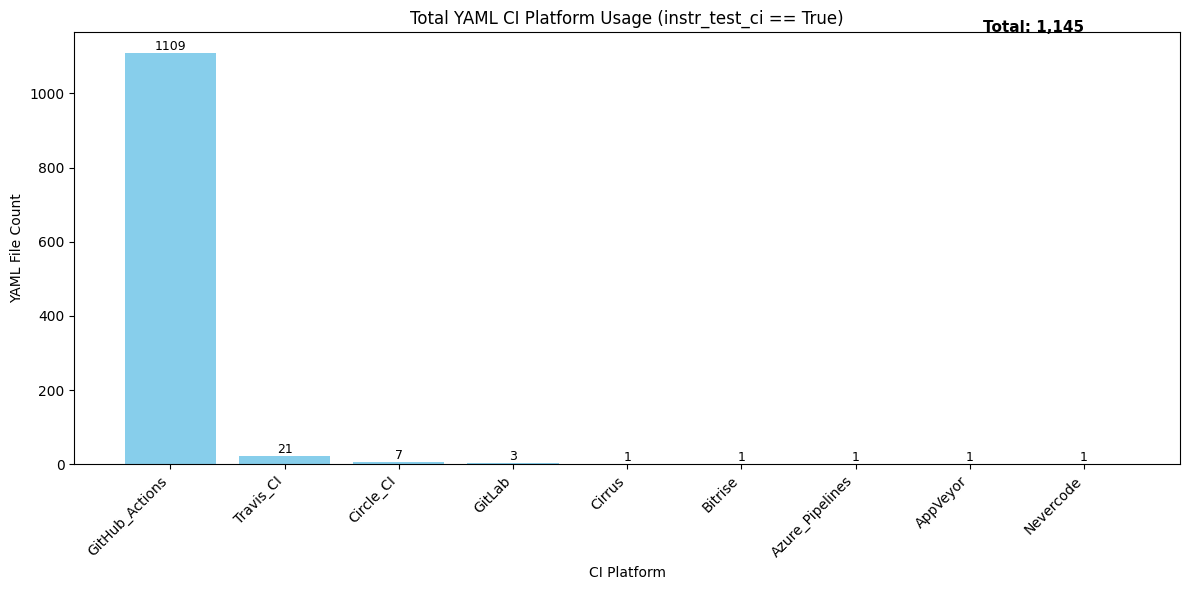

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# === FILE PATH ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Descriptive_Stat_2\3.4_Total_Repos_Tests_DS.csv"

# === LOAD DATA ===
df = pd.read_csv(file_path)

# === FILTER: Only instr_test_ci == True ===
df = df[df['instr_test_ci'] == True]

# === SELECT YML COLUMNS (EXCLUDE 'yml_Error') ===
yml_columns = [col for col in df.columns if col.startswith('yml_') and col.lower() != 'yml_error']

# === CONVERT YML COLUMNS TO NUMERIC (IN CASE OF ANY NON-NUMERIC VALUES) ===
df[yml_columns] = df[yml_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# === CALCULATE TOTAL COUNTS FOR EACH CI PLATFORM ===
ci_totals = df[yml_columns].sum().sort_values(ascending=False)
ci_totals = ci_totals[ci_totals > 0]

# === PLOT ===
plt.figure(figsize=(12, 6))
bars = plt.bar(ci_totals.index.str.replace('yml_', ''), ci_totals.values, color='skyblue')
plt.title('Total YAML CI Platform Usage (instr_test_ci == True)')
plt.xlabel('CI Platform')
plt.ylabel('YAML File Count')

# === ADD LABELS TO EACH BAR ===
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

# === ADD GRAND TOTAL LABEL ===
total_count = int(ci_totals.sum())
plt.text(len(ci_totals)-1, max(ci_totals)*1.05, f'Total: {total_count:,}', ha='right', fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
